# Question 3 — directed functional connectivity

## Final answer: Brain area 1 to brain area 2

This notebook presents the analysis for the question:

> Which brain area pair has the strongest directed functional connectivity?

The inferential unit is the mouse. Connectivity pairs are summarized within each mouse before any group comparison. The expensive 17-mouse directed connectivity and robustness analyses are **not recomputed** here; this notebook loads their saved CSV, JSON, and PNG outputs.

### Notebook roadmap

1. Load one mouse's provided spike times and cluster/area labels as a Pynapple `TsGroup`.
2. Compute population-level directed CCG asymmetry at 2 ms resolution with 100 ms Gaussian detrending.
3. Offer an optional Pynaviz spike-raster inspection.
4. Explain the CCG asymmetry connectivity metric.
5. Load and plot the saved 17-mouse primary results, including 95% bootstrap CIs.
6. Show timescale and trial-only robustness checks and apply the prespecified multiple-choice decision rule.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
from IPython.display import Image, Markdown, display

project = Path.cwd()
if not (project / 'run_q3.py').exists():
    project = project.parent
sys.path.insert(0, str(project))

from run_q3 import (
    Config,
    load_mouse_spikes,
    analyze_mouse,
)

data_dir = project / 'data'
results_dir = project / 'results' / 'q3_connectivity'
cfg = Config()
from importlib.metadata import version
print(f'Python {sys.version.split()[0]} | Pynapple {nap.__version__} | Pynaviz {version("pynaviz")}')

Python 3.11.9 | Pynapple 0.11.3 | Pynaviz 0.2.0


## Why Pynapple?

`TsGroup` keeps each provided unit's timestamps together with its brain-area metadata and time support. We combine the spike times of all units in each area to create population-level spike trains using Pynapple `Ts` and `TsGroup`, and bin them using `.count()`. The cross-correlation and asymmetry calculations are then performed using optimized NumPy operations.

In [2]:
spikes_mouse1, duration_mouse1 = load_mouse_spikes(1, data_dir, cfg)
df_mouse1 = analyze_mouse(1, data_dir, cfg)
display(df_mouse1)

,mouse,scope,detrend_ms,source,target,direction,connectivity_strength
0,1,whole_recording,100,1,2,1to2,0.002255
1,1,whole_recording,100,3,2,3to2,-0.001574
2,1,whole_recording,100,3,1,3to1,0.000846


## Primary directed connectivity measure and justifications

### Step-by-step pipeline:
1. **Population-level pooling**: Combine spikes from all neurons in a brain area to form area-level population activity.
2. **Fine-grained binning**: Bin the population spike trains into 2 ms non-overlapping bins.
3. **High-pass Gaussian detrending**: Filter population activity with a 100 ms Gaussian smoothing kernel and subtract it from the raw counts to obtain high-frequency residuals.
4. **Z-score normalization**: Center and divide by the standard deviation.
5. **CCG lag asymmetry**: Compute the population cross-correlogram (CCG) over positive and negative lags from 2 ms to 50 ms. Calculate directed connectivity strength as the mean difference of the CCG at positive vs. negative lags: $CCG(+lag) - CCG(-lag)$.
6. **Group inference**: Aggregate connectivity strength across the 17 unique mice.

### Pipeline Justifications:
- **2 ms binning**: Resolves fine synaptic-level delays and ensures directed lag interactions can be tracked at a sub-millisecond to millisecond timescale.
- **100 ms Gaussian detrending**: Acts as a high-pass filter. It removes slow, common rate fluctuations and global brain state shifts (which dominate the CCG), leaving only fast, synaptic-timescale interactions.
- **CCG Lag Asymmetry**: Directly measures temporal precedence. If Area A's activity systematically precedes Area B's activity, the CCG at positive lags ($A \rightarrow B$ direction) will be stronger than at negative lags ($B \rightarrow A$ direction). The difference $CCG(+lag) - CCG(-lag)$ measures directed functional connectivity.
- **Mouse-level averaging**: Aggregates population connectivity strengths across independent sessions, allowing robust group-level non-parametric tests ($N=17$) and bootstrapping.

In [3]:
mouse_results = pd.read_csv(results_dir / 'primary_mouse_results.csv')
summary = pd.read_csv(results_dir / 'summary.csv')
tests = json.loads((results_dir / 'statistical_tests.json').read_text())

display(summary)
display(pd.DataFrame(tests['pairwise']))
print('Friedman p =', tests['friedman_p'])

,source,target,direction,candidate,mean,median,ci95_low,ci95_high,n_mice
0,1,2,1to2,Brain area 1 to brain area 2,0.001965,0.001538,0.000605,0.003908,17
1,3,2,3to2,Brain area 3 to brain area 2,-0.002229,-0.001973,-0.003365,-0.001241,17
2,3,1,3to1,Brain area 3 to brain area 1,-0.000381,-0.000038,-0.001103,0.000283,17


,left_pair,right_pair,mean_difference,median_difference,left_wins,right_wins,p_raw,p_holm
0,1to2,3to2,0.004194,0.003829,16,1,0.000381,0.001144
1,1to2,3to1,0.002346,0.001458,13,4,0.017426,0.017426
2,3to2,3to1,-0.001848,-0.001748,3,14,0.000381,0.001144


Friedman p = 9.753550253773386e-05


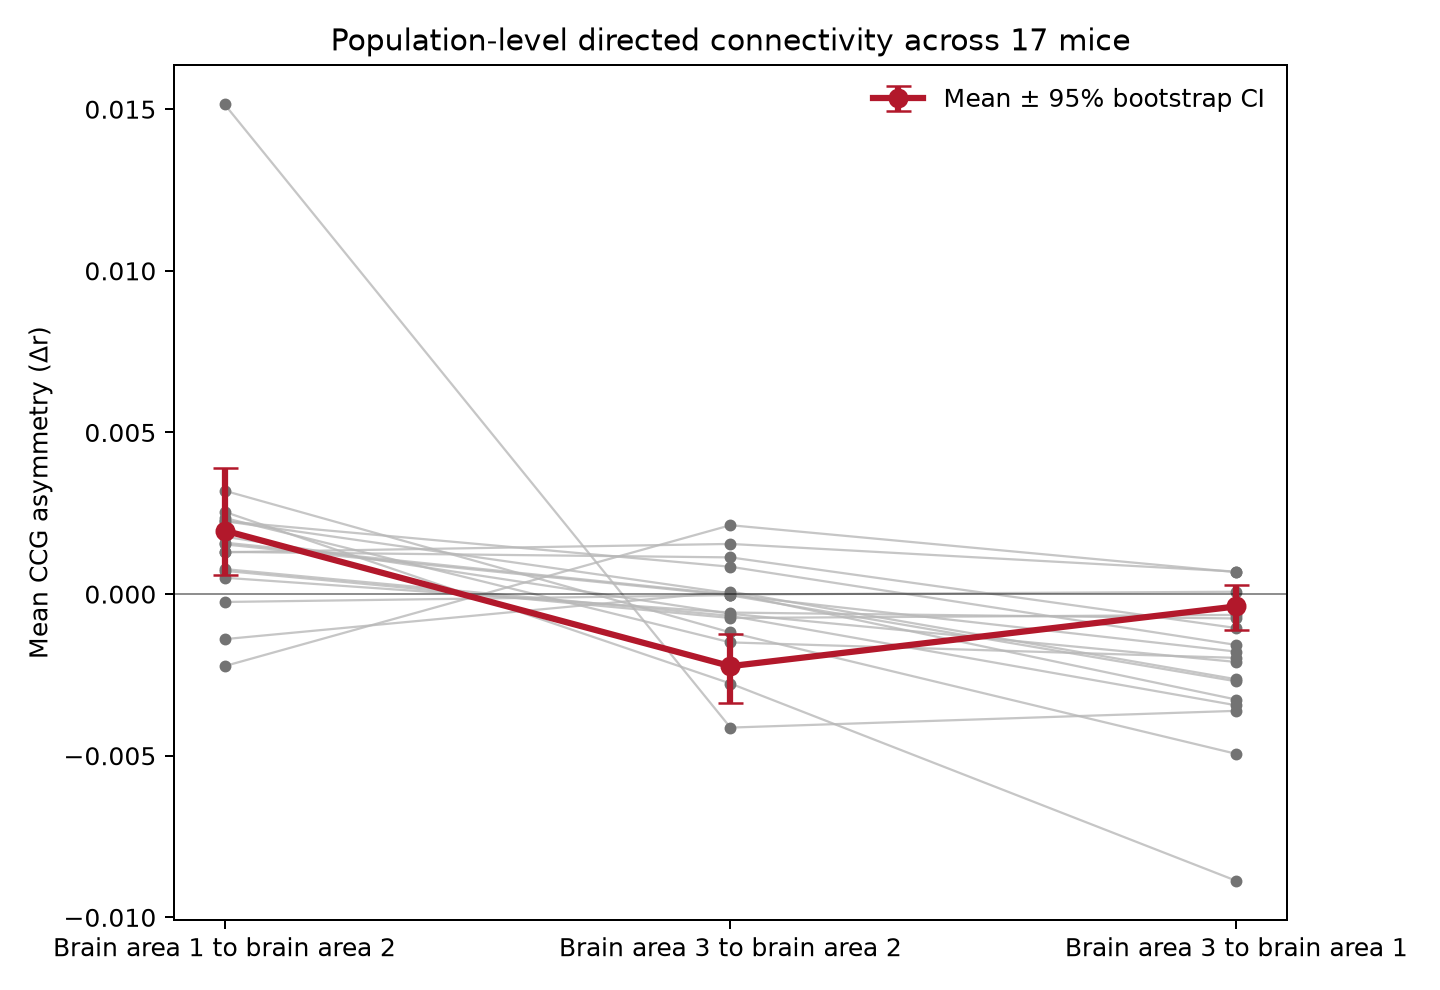

In [4]:
display(Image(filename=str(results_dir / 'paired_mouse_connectivity.png')))

## Robustness checks

Sensitivity analyses evaluate directed connectivity under alternative detrending window sizes (50 ms and 200 ms) and restrict the analysis to task trials only.

In [5]:
sensitivity = pd.read_csv(results_dir / 'sensitivity_results.csv')
display(sensitivity)

,scope,detrend_ms,conn_1to2_mean,conn_3to2_mean,conn_3to1_mean,friedman_p,largest_mean_direction,multiple_choice_answer
0,whole_recording,50,0.001481,-0.001236,-0.000047,0.000021,1to2,Brain area 1 to brain area 2
1,whole_recording,200,0.001728,-0.002529,-0.000355,0.000034,1to2,Not enough data / no significant differences
2,task_trials,100,0.001610,-0.002239,-0.000372,0.000069,1to2,Brain area 1 to brain area 2


## Multiple-choice decision rule

The primary omnibus comparison is a Friedman test across the three paired direction measurements. Pairwise follow-ups use two-sided Wilcoxon signed-rank tests with Holm correction. An area pair direction is selected only if it has the largest mean **and** significantly exceeds both alternatives after correction.

In [6]:
answer = tests['multiple_choice_answer']
display(Markdown(f'### Answer to Question 3: {answer}'))

### Answer to Question 3: Brain area 1 to brain area 2